# Penrose Tiling: Procedural Geometry

Penrose tilings cover the plane with local rules, but the full pattern never repeats by translation. They look ordered without becoming periodic.

Roger Penrose popularized these aperiodic tilings in the 1970s, and a decade later scientists found quasicrystals with similar non-repeating order in real materials. The math sits between art, geometry, crystallography, and procedural generation.

In this notebook, we will build a recursive deflation simulator. We start from a small wheel of golden triangles, repeatedly subdivide each triangle, and plot the result with Matplotlib.

<details>
<summary>Big idea</summary>

A square grid repeats because one patch can slide over and match another patch exactly. A Penrose tiling has structure at many scales, but no repeating shift can line everything up forever.

</details>

## 1. Mental Model

Penrose tiling is a procedural geometry problem:

- Start with legal shapes.
- Apply a local subdivision rule.
- Repeat the rule many times.
- A non-repeating global pattern emerges.

We will use two golden triangles: a **thin** triangle and a **thick** triangle. Pairs of these triangles can be viewed as the kite/dart or rhombus pieces often used to explain Penrose tilings.

<details>
<summary>Why triangles?</summary>

Triangles make the deflation rule simple. The familiar larger Penrose pieces are built by gluing these triangles along matching edges.

</details>

## 2. Build the Objects

We will model the geometry directly:

- `PenroseTriangle` stores one triangle and knows how to deflate itself.
- `TilingSnapshot` records one generation of triangles.
- `PenroseTiling` starts from a seed pattern and repeatedly applies deflation.
- A plotting helper turns triangles into `matplotlib.patches.Polygon` objects.

<details>
<summary>Implementation hint</summary>

Complex numbers are a clean way to store 2D points. The real part is `x`; the imaginary part is `y`.

</details>

**Helper functions.** Define `point_at`, `to_xy` so the later cells stay focused on behavior.


In [ ]:
from collections import Counter

from dataclasses import dataclass

import math

import matplotlib.pyplot as plt

from matplotlib.collections import PatchCollection

from matplotlib.patches import Polygon

PHI = (1 + math.sqrt(5)) / 2

TAU = 2 * math.pi

def point_at(angle: float, radius: float = 1.0) -> complex:
    return radius * complex(math.cos(angle), math.sin(angle))

def to_xy(point: complex) -> tuple[float, float]:
    return (point.real, point.imag)


**Object model.** Define `PenroseTriangle`, the named objects used by the next examples.


In [ ]:
@dataclass(frozen=True)
class PenroseTriangle:
    kind: str
    a: complex
    b: complex
    c: complex
    generation: int = 0

    def vertices(self) -> list[tuple[float, float]]:
        return [to_xy(self.a), to_xy(self.b), to_xy(self.c)]

    def area(self) -> float:
        return abs(
            self.a.real * (self.b.imag - self.c.imag)
            + self.b.real * (self.c.imag - self.a.imag)
            + self.c.real * (self.a.imag - self.b.imag)
        ) / 2

    def deflate(self) -> list["PenroseTriangle"]:
        next_generation = self.generation + 1

        if self.kind == "thin":
            split_point = self.a + (self.b - self.a) / PHI
            return [
                PenroseTriangle("thin", self.c, split_point, self.b, next_generation),
                PenroseTriangle("thick", split_point, self.c, self.a, next_generation),
            ]

        if self.kind == "thick":
            left_split = self.b + (self.a - self.b) / PHI
            right_split = self.b + (self.c - self.b) / PHI
            return [
                PenroseTriangle("thick", right_split, self.c, self.a, next_generation),
                PenroseTriangle("thick", left_split, right_split, self.b, next_generation),
                PenroseTriangle("thin", right_split, left_split, self.a, next_generation),
            ]

        raise ValueError(f"Unknown triangle kind: {self.kind}")


**Trace model.** Define `TilingSnapshot`, the structure used to capture replayable algorithm state.


In [ ]:
@dataclass(frozen=True)
class TilingSnapshot:
    generation: int
    triangles: tuple[PenroseTriangle, ...]

    def counts(self) -> Counter:
        return Counter(triangle.kind for triangle in self.triangles)

    def total_area(self) -> float:
        return sum(triangle.area() for triangle in self.triangles)


**Object model.** Define `PenroseTiling`, the named objects used by the next examples.


In [ ]:
class PenroseTiling:
    def __init__(self, triangles: list[PenroseTriangle]):
        self.triangles = triangles
        self.generation = triangles[0].generation if triangles else 0

    @classmethod
    def sun_seed(cls) -> "PenroseTiling":
        triangles: list[PenroseTriangle] = []
        center = 0 + 0j

        for index in range(10):
            left = point_at((2 * index - 1) * math.pi / 10)
            right = point_at((2 * index + 1) * math.pi / 10)
            if index % 2 == 0:
                left, right = right, left
            triangles.append(PenroseTriangle("thin", center, left, right))

        return cls(triangles)

    def snapshot(self) -> TilingSnapshot:
        return TilingSnapshot(self.generation, tuple(self.triangles))

    def deflate_once(self) -> TilingSnapshot:
        self.triangles = [child for triangle in self.triangles for child in triangle.deflate()]
        self.generation += 1
        return self.snapshot()

    def run(self, generations: int) -> list[TilingSnapshot]:
        snapshots = [self.snapshot()]
        for _ in range(generations):
            snapshots.append(self.deflate_once())
        return snapshots


**Visual helper.** Define `plot_tiling`, which turns state into something students can inspect.


In [ ]:
def plot_tiling(snapshot: TilingSnapshot, title: str | None = None, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    colors = {"thin": "#2A9D8F", "thick": "#E9C46A"}
    patches = [Polygon(triangle.vertices(), closed=True) for triangle in snapshot.triangles]
    facecolors = [colors[triangle.kind] for triangle in snapshot.triangles]
    collection = PatchCollection(
        patches,
        facecolor=facecolors,
        edgecolor="#1F2933",
        linewidth=0.18,
        alpha=0.95,
    )
    ax.add_collection(collection)
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is None:
        counts = snapshot.counts()
        title = (
            f"generation {snapshot.generation}: "
            f"{len(snapshot.triangles)} triangles "
            f"({counts['thin']} thin, {counts['thick']} thick)"
        )
    ax.set_title(title)


## 3. Run Deflation

Deflation is the recursive rule:

- A thin triangle becomes one thin triangle and one thick triangle.
- A thick triangle becomes two thick triangles and one thin triangle.

Run the rule several times and the triangle count grows quickly.

<details>
<summary>Fractal geometry hint</summary>

Each generation uses the same local rule on every piece. That is why small regions start resembling larger regions as the tiling grows.

</details>

In [2]:
tiling = PenroseTiling.sun_seed()
snapshots = tiling.run(generations=6)

print("generation | triangles | thin | thick | thick/thin")
print("-" * 52)
for snapshot in snapshots:
    counts = snapshot.counts()
    ratio = counts["thick"] / counts["thin"] if counts["thin"] else float("nan")
    print(
        f"{snapshot.generation:>10} | "
        f"{len(snapshot.triangles):>9} | "
        f"{counts['thin']:>4} | "
        f"{counts['thick']:>5} | "
        f"{ratio:>10.4f}"
    )

print(f"\nGolden ratio: {PHI:.4f}")

generation | triangles | thin | thick | thick/thin
----------------------------------------------------
         0 |        10 |   10 |     0 |     0.0000
         1 |        20 |   10 |    10 |     1.0000
         2 |        50 |   20 |    30 |     1.5000
         3 |       130 |   50 |    80 |     1.6000
         4 |       340 |  130 |   210 |     1.6154
         5 |       890 |  340 |   550 |     1.6176
         6 |      2330 |  890 |  1440 |     1.6180

Golden ratio: 1.6180


## 4. Plot the Generations

The first generations look simple. By generation 6, the same rule has created thousands of pieces and a mandala-like structure.

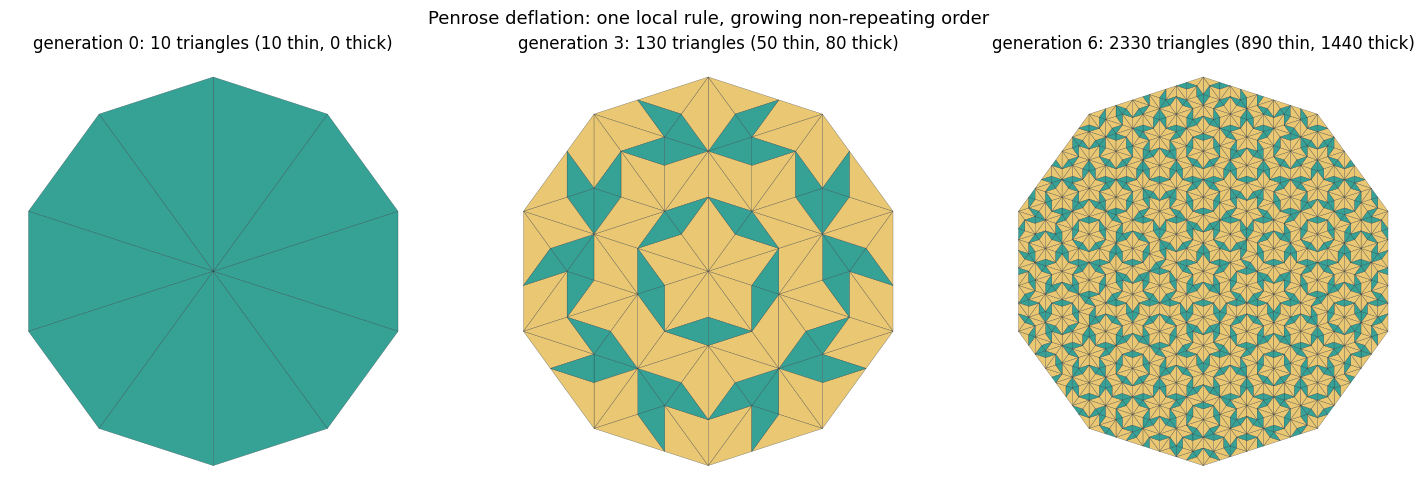

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, generation in zip(axes, [0, 3, 6]):
    plot_tiling(snapshots[generation], ax=ax)

fig.suptitle("Penrose deflation: one local rule, growing non-repeating order", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Replay the Recursion

The algorithm is short, but the growth is dramatic. A replay summary helps separate the simple local rule from the complex global result.

In [4]:
class DeflationReplay:
    def __init__(self, snapshots: list[TilingSnapshot]):
        self.snapshots = snapshots

    def show(self) -> None:
        previous_total = None
        for snapshot in self.snapshots:
            counts = snapshot.counts()
            growth = "seed" if previous_total is None else f"x{len(snapshot.triangles) / previous_total:.2f}"
            print(
                f"generation={snapshot.generation} "
                f"triangles={len(snapshot.triangles):>4} "
                f"thin={counts['thin']:>4} "
                f"thick={counts['thick']:>4} "
                f"growth={growth}"
            )
            previous_total = len(snapshot.triangles)


DeflationReplay(snapshots).show()

generation=0 triangles=  10 thin=  10 thick=   0 growth=seed
generation=1 triangles=  20 thin=  10 thick=  10 growth=x2.00
generation=2 triangles=  50 thin=  20 thick=  30 growth=x2.50
generation=3 triangles= 130 thin=  50 thick=  80 growth=x2.60
generation=4 triangles= 340 thin= 130 thick= 210 growth=x2.62
generation=5 triangles= 890 thin= 340 thick= 550 growth=x2.62
generation=6 triangles=2330 thin= 890 thick=1440 growth=x2.62


## 6. Playground: Choose a Generation

Higher generations are more detailed, but they also create many more patches. Generation 6 is a good notebook-sized balance: detailed enough to look intricate, small enough to render quickly.

<details>
<summary>Performance hint</summary>

Matplotlib can draw thousands of polygons, but generation 8 and beyond can become slow in a notebook. Increase depth one step at a time.

</details>

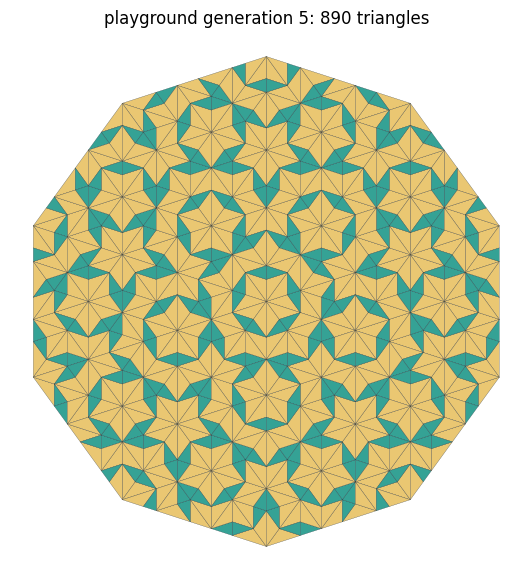

In [5]:
def build_penrose_snapshot(generation: int) -> TilingSnapshot:
    if generation < 0:
        raise ValueError("Generation must be non-negative.")
    playground_tiling = PenroseTiling.sun_seed()
    return playground_tiling.run(generation)[-1]


playground_generation = 5
playground_snapshot = build_penrose_snapshot(playground_generation)

plot_tiling(
    playground_snapshot,
    title=f"playground generation {playground_generation}: {len(playground_snapshot.triangles)} triangles",
)
plt.show()

## 7. Experiment: Zoom the Mandala

Penrose tilings are ordered, but not periodic. A zoomed section contains repeated-looking local motifs without becoming a simple copy-paste grid.

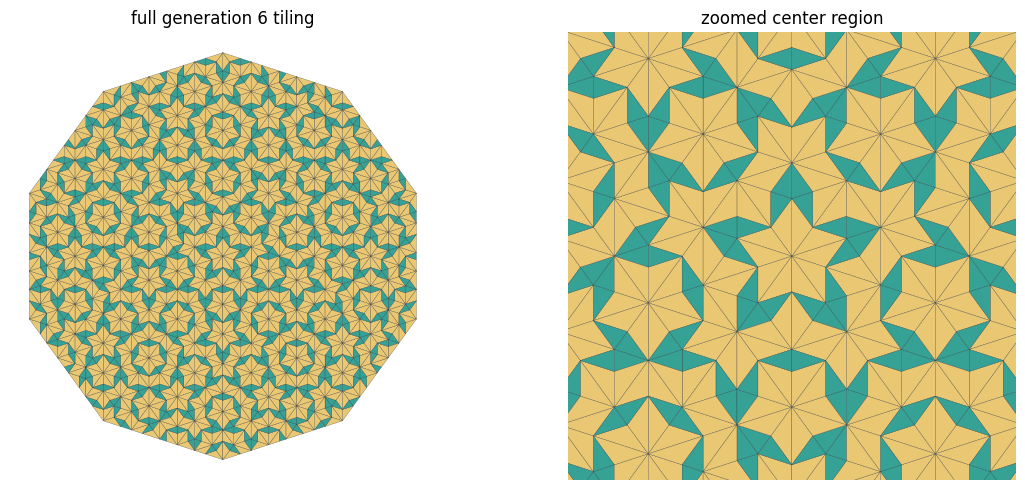

In [6]:
zoom_snapshot = snapshots[6]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_tiling(zoom_snapshot, title="full generation 6 tiling", ax=axes[0])
plot_tiling(zoom_snapshot, title="zoomed center region", ax=axes[1])
axes[1].set_xlim(-0.35, 0.35)
axes[1].set_ylim(-0.35, 0.35)

plt.tight_layout()
plt.show()

## 8. Why This Is Aperiodic

The seed we used is a symmetric wheel because it makes a strong first visual. The important part is the **deflation rule**: every triangle is replaced by smaller legal triangles using the golden ratio.

That local rule creates long-range order without a repeating grid. This is why Penrose tilings became connected to quasicrystals: some materials have atomic arrangements with order, symmetry, and sharp diffraction patterns, but no ordinary repeating unit cell.

<details>
<summary>Geometry note</summary>

A finite plot can have visible symmetry because of its seed. Aperiodicity is about the infinite tiling: no translation can shift the entire infinite pattern onto itself.

</details>

## 9. What You Should Remember

- Penrose tilings are ordered but non-repeating.
- Deflation is recursion applied to geometry.
- The golden ratio controls where each triangle is split.
- Thin and thick triangle counts approach the golden ratio.
- Matplotlib patches let you turn abstract recursive geometry into a visible procedural pattern.

<details>
<summary>Next experiment</summary>

Try changing `playground_generation` from `5` to `6` or `7`. The rule stays the same, but the visible structure becomes much richer.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Create non-repeating order through recursive geometric substitution.

**Interactive animation target.** Animate deflation steps, color tile types, and preserve matching constraints.

**Correctness handle.** Each substitution preserves the local matching rules that prevent periodic repetition.

**Complexity handle.** Tile count grows exponentially with deflation depth.

**Failure mode to test.** Floating-point drift can create tiny cracks unless geometry is handled carefully.

**Studio task.** Track one tile lineage through two deflations and explain what changes and what persists.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
